# Introduction

The objective of this project is to build and optimize multiple linear regression models to predict life expectancy using socioeconomic and health-related factors. Through data preprocessing, feature selection, cross-validation, and PCA(Principal Component Analysis), the project evaluates different modeling approaches to identify a model that balances predictive accuracy and simplicity.


The original dataset contains 22 columns, including country, year, status, adult mortality, infant deaths, alcohol, percentage expenditure, hepatitis B, measles, BMI, under-five deaths, Polio, Total expenditure, diphtheria, HIV/AIDS, GDP, Population, thinness 1-19 years, thinness 5-9 years, Income composition of resources, schooling years, and life expectancy rate. 

At first glance, the dataset contains many missing values. With missing values, it is difficult to accurately predict a variable. Thus, both a reshaping data function and a data preprocessing function are needed to clean the data before building regression models.

# Data Preprocessing

## ***reshape_life expectancy*** function

To address the messy data issue, a reshape_life expectancy function is designed. This function performs some basic cleaning of the data by fixing column names and removing rows with missing life expectancy values. When insepecting the dataset, there are a lot of zero values in 'status', 'country', and 'year ' variables, which are not realistic and could bias the later analysis. Thus, rather than treating these zeros as valid observations, they are converted to missing values (NaN) to prevent biased results. 
In addition, several variables are log-transformed to reduce skewness. In real life, many socioeconomic variables, such as GDP and population, tend to have highly skewed distributions with extreme values. This transformation could make relationships between variables more linear and reduce the influence of outliers, improving the performance of multilinear regression models. 
Lastly, one important step in this function is converting a categorical variable 'status' that distinguishes between developing and developed countries into a dummy variable. This allows us to include country status as a numerical predictor and the model can capture potential structural differences between countries.
Overall, this function returns a cleaned and transformed dataset. 

## ***data_preprocessing*** function

The second function is the data_preprocessing. It returns the processed training, test datasets, and the chosen regressors, preparing the data for model fitting. This function takes 8 inputs: 

In [ ]:
def data_preprocessing(X_train,X_test,y_train,y_test,regressors=None,
                       interaction=False,use_pca=False, pcs=None)

First, this function converts unrealistic zeros in several columns into NaN values. Since missing values still remain, forward-fill and backward-fill methods are used so that nearby values from the same country can help fill missing entries. After this, in order to avoid data leakage, the same filling logic is applied to the test set. 

In addition to handling missing values, the function proceeds to select predictors based on the given set of regressors and optionally incorporates interaction terms if requested. If principal components are specified, the function fits a PCA transformation on the training data and applies the same transformation to both the training and test sets.

Among the steps in this preprocessing pipeline, one remarkable step I would like to emphasize is the use of K-Nearest Neighbors (KNN) imputation to handle remaining missing values. Specifically, the KNN method fills missing values in the training set with the weighted average of its nearest neighbors. Here, I used k=5 because it is a reasonable starting value in the imputation process. An important note is that we should always standardize the data before applying KNN imputation. After the missing values are filled, the data is transformed back to its original scale. 

In [ ]:
# Use KNN to infer missing values (must exclude 'population', 'country' from this process)
    drop_features = ['population', 'country']
    X_train_knn = X_train.drop(columns = drop_features)
    X_test_knn = X_test.drop(columns = drop_features)

    scaler = StandardScaler()
    scaler.fit(X_train_knn)
    X_train_rescaled = scaler.transform(X_train_knn)
    X_test_rescaled = scaler.transform(X_test_knn)

    #5 is a good value 
    knn_imputer = KNNImputer(n_neighbors=5, weights = 'distance', metric='nan_euclidean')
    knn_imputer.fit(X_train_rescaled)

    X_train.loc[:, X_train_knn.columns] = scaler.inverse_transform(knn_imputer.transform(X_train_rescaled))
    X_test.loc[:, X_test_knn.columns] = scaler.inverse_transform(knn_imputer.transform(X_test_rescaled))

Another part in this function I would like to highlight is the creation of interaction terms. I created two interaction terms: status x GDP and status x hiv_aids because the effect of these variables on life expectancy may not be the same in all countries. Particularly, I think that an increase in GDP or in hiv/aids prevalence may have a stronger impact on life expectancy in developing countries as economic improvement can seriously increase access to healthcare and sanitation in those countries. By adding interaction terms, I believe it will make the model better capture real-world differences and make better predictions. 

In [ ]:
# Interaction terms (ex, creating status - 0 or 1)
    if (interaction == True):
        #created two interaction terms: status x gdp and status x hiv_aids
        variables = ' + '.join(regressors)+ ' + status:gdp + status:hiv_aids' 
        X_train = dmatrix(variables, X_train, return_type='dataframe')
        X_test = dmatrix(variables, X_test, return_type='dataframe')
        regressors = X_train.columns.tolist()

# Multilinear regression

## ***multilinear_regression*** function

After preprocessing the data, I designed a multilinear regression function to train and evaluate a regression model. It first calls the data preprocessing function. Then it fits a linear regression on the x_train data and generates predictions for both y_train and y_test.

To evaluate model performance, the function computes R^2 score, RMSE, F-Stats, and residuals for both the training and the test sets. It returns these performance metrics and the regressors used, allowing us to easily compare different models.

In [ ]:
def multilinear_regression(X_train,X_test,y_train,y_test,regressors = None,
                           interaction = False, use_pca = False, pcs= None, residuals =False)

# Model validation 

## ***model_validation_multi_regression*** function

Although the multilinear regression function provides a way to fit and evaluate a model, it is not sufficient for selecting the best one among multiple models. A key component of this function is the use of k-fold cross-validation. Instead of evaluating the model based on a single train-test split, I included the k-fold cross-validation. It splits the training data into k=5 smaller subsets. In each iteration, the model is trained on a portion of the data and validated on the remaining subset. This process is repeated nbr_loops =10 times using different data splits. These metrics across all folds are then averaged to measure overall validation performance. Finally, the function returns the performance metrics (R^2, RMSE, F-stat) for both the k-fold validation and the test set.

I incorporated the design of k-fold cross-validation because it can prevent the case of obtaining misleading results from a single unrepresentative train-test split. By averaging performance over multiple splits, k-fold cross-validation can provide us a more reliable evaluation of the model's performance.

In [ ]:
def model_validation_multi_regression(test_size=.35,split_seed=1234,
                                      cv_seed=54321,k=5,
                                      nbr_loops=10,regressors = None,
                                      interaction= False,use_pca = False,
                                      pcs = None,scores_only=False)

# Designing optimized multilinear regression model without PCA

To build a multilinear regression model without pca, I need to identify what variables are more likely to contribute to accurately predicting life expectancy. I explored two approaches for model selection: a comprehensive approach and a progressive selection approach. 

## **Comprehensive Approach**

For the comprehensive approach, due to the computational cost of evaluating all possible combinations of regressors(since there are 19 regressors), I decided to select variables that showed strong correlation with life expectancy and tried combinations of the top ones. 

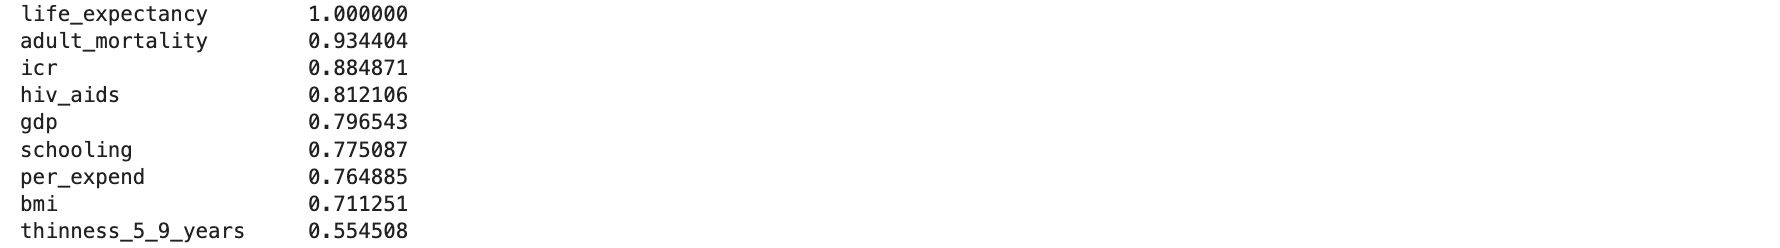

The result shows that the top six features that most strongly correlated with life_expectancy are {adult_mortality, icr, hiv_aids, gdp, schooling, per_expend}. I placed these six features into a set and generated all possible combinations of size two to five. 

For each combination, I trained a multilinear regression model and evaluated its performance using repeated k-fold cross-validation (k = 5, repeated 10 times). After this, I examined which combinations produced the lowest k-fold RMSE and the highest k-fold R^2 score, and ranked the results accordingly based on these metrics.

In [ ]:
top_features = {'adult_mortality','icr','hiv_aids','gdp','schooling','per_expend'} # these are the top 6 features

# generate all combinations
all_combinations = set()

for k in np.arange(2, 6):  
    for c in combinations(top_features, k):
        all_combinations.add(c)

all_combinations = tuple(all_combinations)

#run all models
res = [model_validation_multi_regression(k=5,nbr_loops=10,regressors=list(combination),
    interaction=False,use_pca=False, pcs=None,scores_only=True)
    for combination in all_combinations]

Here is the result of the top 5 rows:

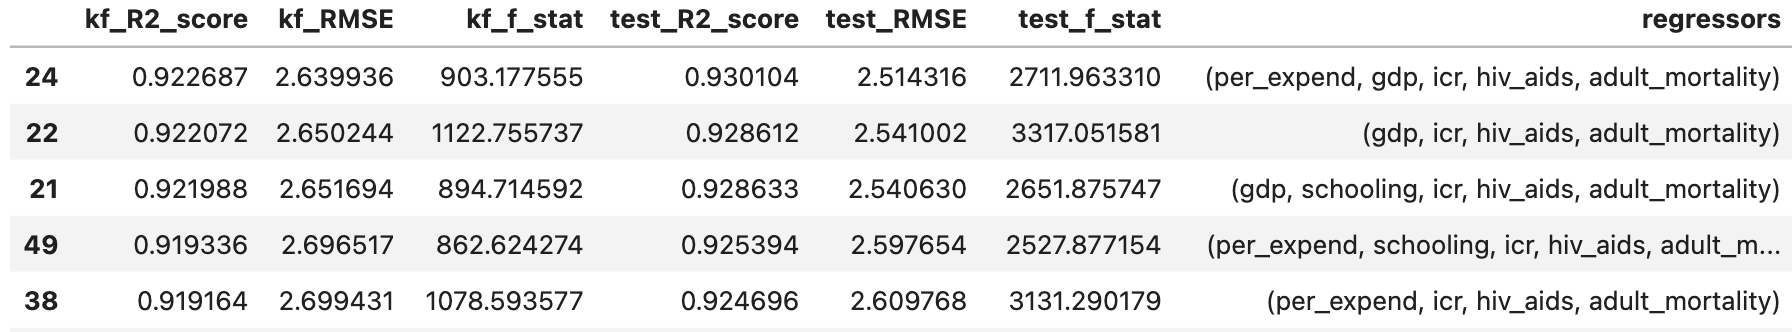

The result shows that the model with the lowest k-fold RMSE and highest k-fold RMSE is the five-variable model with regressors = {per_expend, gdp, icr, hiv_aids, adult_mortality}. However, if we take a look at the second-best model with 4 regressors, the difference in k-fold R^2 compared to the five-variable model is negligible (approximately 0.0006), and the difference in k-fold RMSE is only about 0.011.

Although the five-variable model achieves the lowest k-fold RMSE, the improvement compared to the four-variable model is very small. A simple model with fewer regressors is always better than a complex model with more regressors since models with more regressors encounter a greater risk of overfitting. **Therefore, under the comprehensive approach, I considered the model with four regressors {gdp, icr, hiv_aid, adult_mortality} as an optimized one.**


## **Progressive selection Approach**

Building on the comprehensive approach, I also implemented a progressive selection method to see if it could produce a model with a better result. Unlike the comprehensive approach, which tests all possible combinations of the chosen set, this approach begins with an empty model and adds predictors one at a time. At each step, I evaluated all remaining variables by temporarily adding each one to the current model and computing the corresponding repeated k-fold RMSE (k = 5, repeated 3 times). I reduced nbr_loops to 3 because there are 19 features to be tested, and choosing 10 would take an extremely long time. I then selected the variable that produced the lowest RMSE and kept it in the model. This progressive method is effective because it selects the variable that provides the greatest improvement at each step.

In [ ]:
features = X.drop(columns=['country', 'population']).columns.tolist() #drop country and population
selected_features = []

#At each step, try adding each remaining feature, and keep the one that gives the lowest k-fold RMSE
while (len(features) > 0):
    all_res = []
    for regressor in features:
        combination = selected_features.copy()
        combination.append(regressor)

        res = model_validation_multi_regression(test_size=.35,split_seed=1234,
            cv_seed=54321,k=5,nbr_loops=3,regressors=combination,
            interaction=False,use_pca=False,pcs=None,scores_only=True)

        all_res.append(res)

    added_regressor = pd.DataFrame.from_dict(all_res)\
        .assign(added_regressor = features)\
        .sort_values(by='kf_RMSE', ascending=True)\
        .iloc[0, :].loc['added_regressor']

    selected_features.append(added_regressor)
    features.remove(added_regressor)

I then evaluated the progressive selection results. First, I constructed a series of nested models, where the first model used the top selected predictor, the second used the top 2 predictors, and so on. For each model, I computed performance metrics. After that, I compared the models based on their k-fold RMSE and k-fold R^2 score, prioritizing models with lower prediction error and higher explanatory power.

To better understand the results, I visualized the results by plotting both k-fold and test RMSE, R^2, and F-statistics against the number of regressors. 

**The results are shown below:**

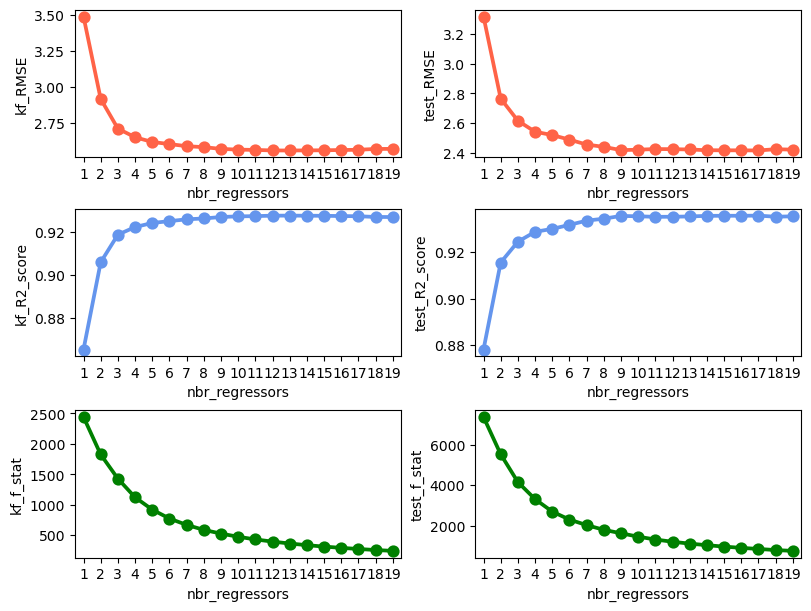

The plots show that model performance greatly improves when the number of regressors increases from 1 to 4. Specifically, RMSE decreases significantly and R^2 increases quickly within this range. 

What's important to note is that the improvements in RMSE and R^2 after 4 are minimal. I think selecting 4 regressors would produce an optimized model because a simpler model with fewer regressors is less likely to overfit. 

**Here is the model validation result of the 4-variable model:**

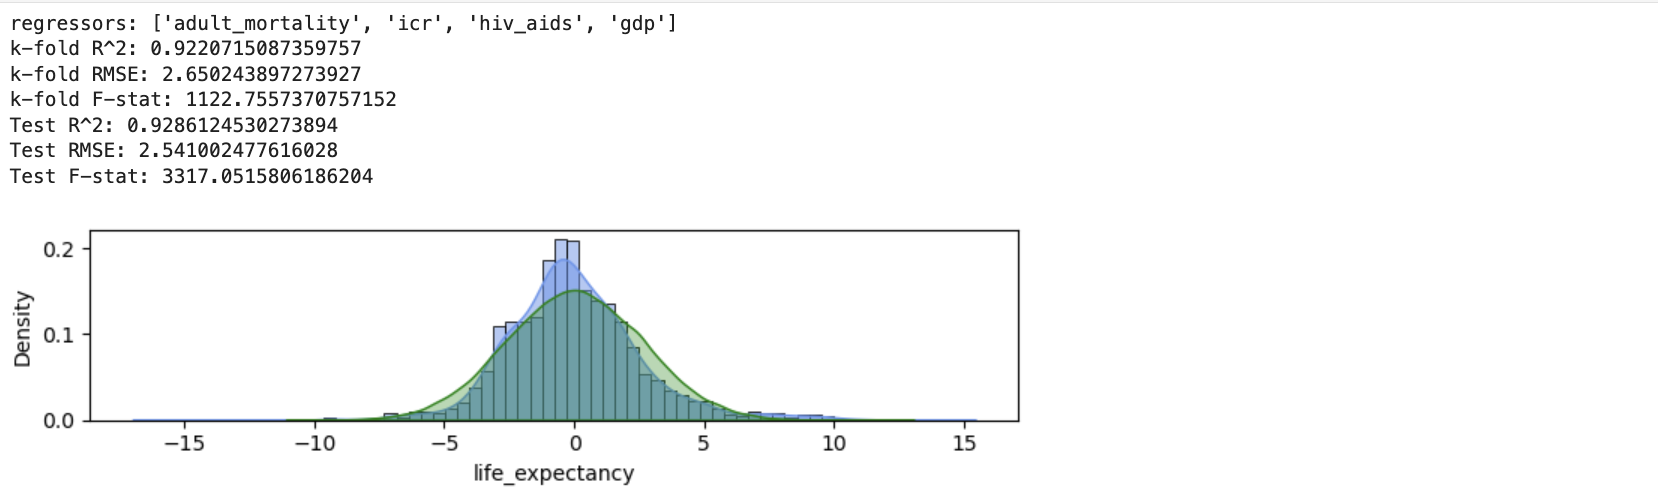

## Result: comprehensive approach vs. progressive selection approach

Comparing the results of the comprehensive approach and the progressive selection, I have found that both strategies indicate the model with four regressors {adult_mortality, icr,hiv_aids, and gdp }, is the optimized model without PCA. Personally, I believe this 4-variable model is strong because it achieves a low k-fold RMSE of 2.65 and a high k-fold R^2 of 0.92, meaning the model has high predictive accuracy and successfully explains 92% of the variability in the response variable, life expectancy. The performance metrics on the test data also perform well and are consistent with the k-fold results, which suggests this model is not overfitting. 

### Comparison of the Optimal Model With and Without Interaction Terms

In the data preprocessing function, I included an additional predictor, *status*, and two interaction terms: *status × gdp* and *status × hiv_aids*. Since the four-variable model (adult_mortality, icr, hiv_aids, and gdp) was identified as optimal, I would like to test the same model with interaction terms added to see if they improve the model performance. What I did was I set the interaction = True when calling the model_validation_multi_regression() function. 

**The results for the model with interaction terms added are shown below:**

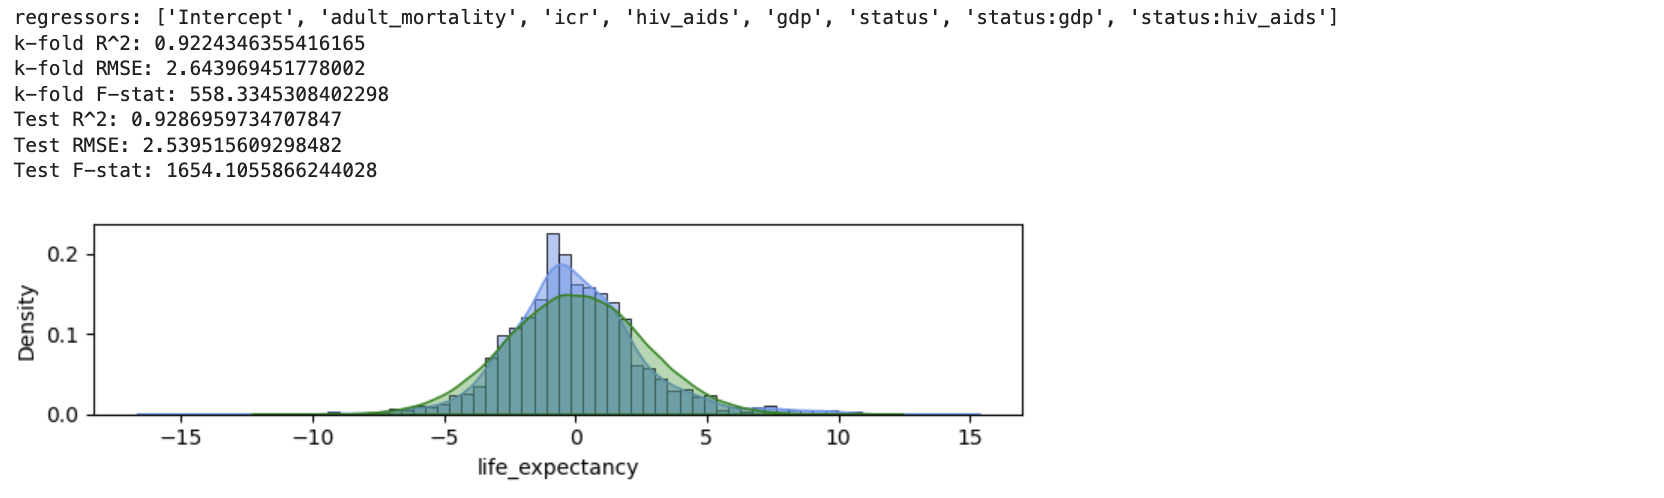

## Conclusion:

Comparing the k-fold R^2 and k-fold RMSE of the 4-variable model with and without interaction terms, I discovered that interaction terms slightly improve performance. However, since the gain is very minimal, adding interaction terms is not necessary in this case.

Thus, I concluded that **the optimized multilinear regression model without PCA** is **the model with four regressors: *adult_mortality, icr, hiv_aids, and gdp***. Interatcion terms are not necessarily required for this model.

# Designing an optimized multilinear regression model using PCA

In the previous section, I built and evaluated an optimized model without PCA using the original set of predictors. In this section, I applied Principal Component Analysis (PCA) to transform the predictors into orthogonal components. PCA is a useful technique to convert the original predictors into a set of uncorrelated components and reduce the dimensionality of a large dataset, which helps increase interpretability and addresses potential multicollinearity present in the original predictors.

Similar to strategies used for the model without PCA, I constructed and evaluated the PCA-based model using two methods: a progressive selection approach based on correlation with the life expectancy, and a more exhaustive progressive selection approach.

## Progressive selection based on correlation with life expectancy

The first step is always clearing and preprocessing. As in the previous section, I first called the *reshaped life_expectancy()* and *data_preprocessing()* functions to clean and prepare the data for model building. Particularly, when calling data_proprocessing(), I set *use_pca = true* this time, which allows the function to standardize the predictors and apply PCA to transform the original predictors into orthogonal components. 

After that, one crucial step I took was to rank the principal components by how strongly they are correlated to life expectancy and store them in *pc_ranking* in descending order. 

In [ ]:
# Selecting the pcs being the most correlated to the outcome, life expectancy
pc_ranking = pd.DataFrame(X_train_pca).corrwith(y_train_pca.reset_index(drop=True) 
             ).abs().sort_values(ascending=False).index.tolist()

Starting with an empty list *res*, I built a sequence of PCA models by progressively adding principal components one at a time based on their correlation with life expectancy. A notable detail is that, when calling *model_validation_multi_regression()*, the argument *pcs* is set to *pc_ranking[:i]*, which selects the top i principal components ranked by their correlation with y. 

**Here is the result showing the relationship between the number of components and model performance metrics:**

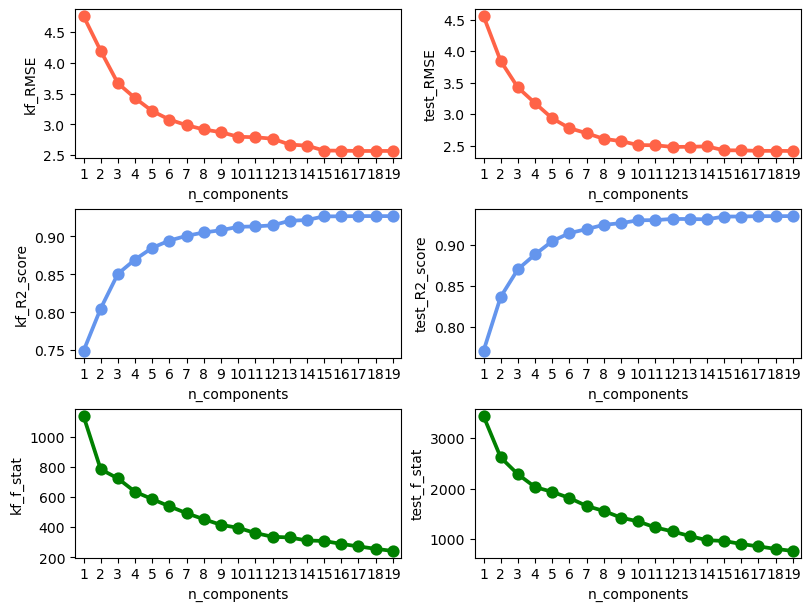

It is clear from the plots that kf_R^2 rapidly increases from n_components = 1 to 14. Beyond 14, the R^2 seems to fluctuate slightly.  Similarly, kf_RMSE decreases significantly from 1 to 14, and the change after 14 is not obvious. I believe n_components = 14 is an optimal value because kf_R^2 improves little beyond 14, and having too many principal components will make the model too complicated and increase the risk of overfitting. 

**Therefore, I selected 14 components and examined the corresponding model validation results.**

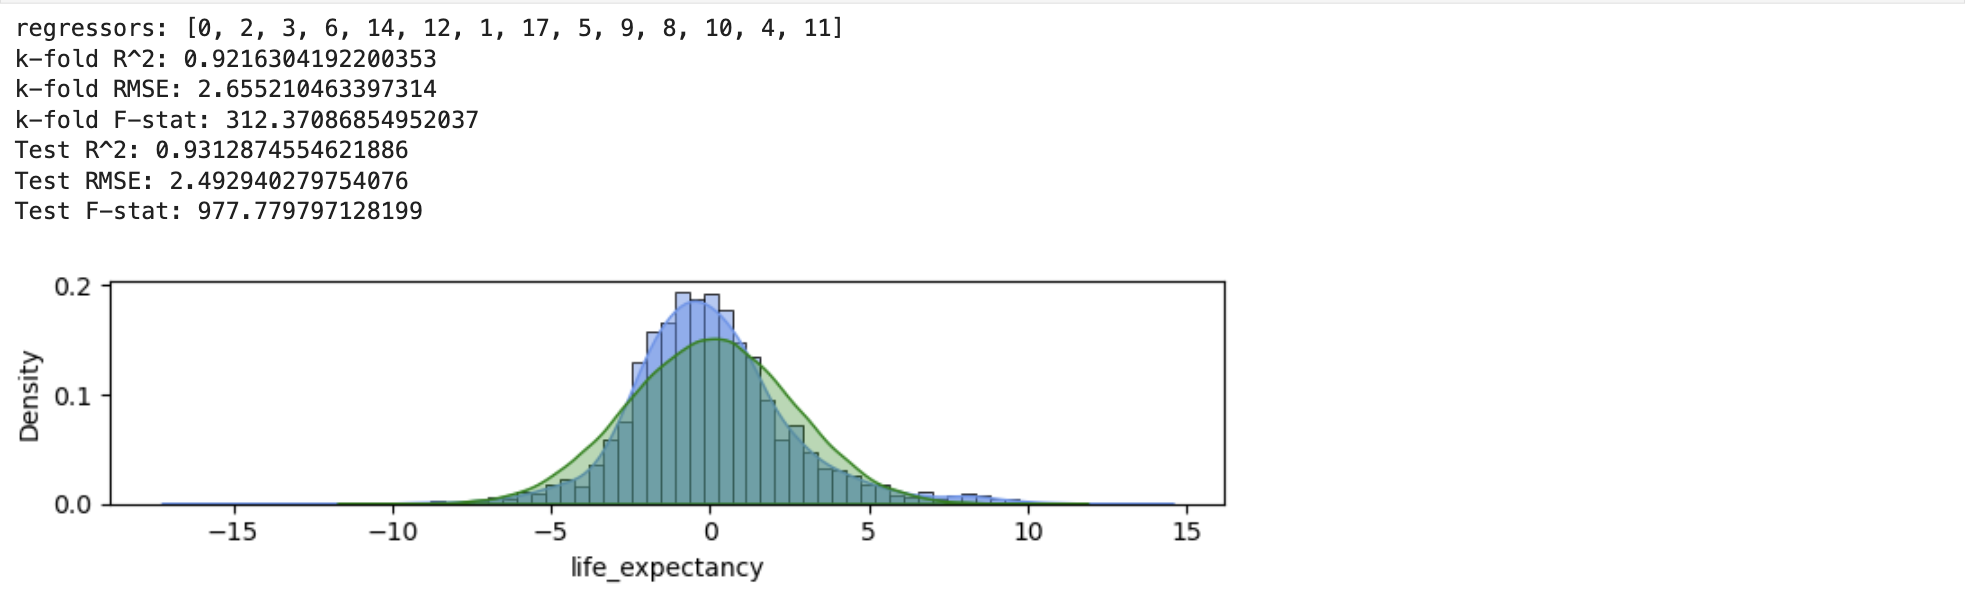

## Exhaustive progressive selection

I also implemented an exhaustive progressive selection approach. This method is very similar to the progressive selection procedure used for the model without PCA, except that the predictors are now principal components rather than the original features. I first began with an empty model. At each step, I constructed multiple models by temporarily adding each remaining principal component to the current model, evaluated their performance using k-fold RMSE, and selected the component with the lowest k-fold RMSE for the model. 

After determining the order of selected components, I created a sequence of nested PCA models, where the first model uses the top selected component, the second model uses the top two selected components. I then compared their performance using k-fold RMSE, k-fold R^2, and k-fold f-stat. Lastly,  I visualized the results by plotting both k-fold and test RMSE, R^2, and F-statistics against the number of regressors.

## Result: Progressive selection based on correlation vs. Exhaustive progressive selection

The exhaustive progressive selection presents the same plotting result as the progressive selection based on correlation. I believe this is because principal components are orthogonal. As a result, selecting components by their correlation with the response and selecting them progressively based on model improvement contributed to the same ordering of components and therefore the same performance metric curves.

## Conclusion:

For the PCA-based model, I selected **the optimal model with 14 principal components**, which achieves a k-fold R^2 of 0.92 and a k-fold RMSE of 2.66.

# Final Comparison: Non-PCA model vs. PCA model

The results of both optimized models achieve nearly the same performance. This suggests that PCA does not significantly improve accuracy for this dataset.

Moving forward as a data scientist, a takeaway I have gained from this lab is that PCA is a useful tool, but it does not necessarily outperform models built using the original predictors. The second takeaway is that simpler models are often better when performance is similar, as simplicity prevents models from overfitting.